# Diagnostic de Défauts dans les Moteurs CC 12V par Apprentissage Automatique
# Classification Multi-Classe pour Déploiement sur Microcontrôleur ESP32

---

**Projet** : Système embarqué de détection de défauts pour petits moteurs à courant continu 12V

**Plateforme cible** : ESP32 (microcontrôleur basse consommation)

**Approche** : Classification supervisée à 3 classes à partir de signaux capteurs

**Dataset** : ITSC Dataset — Signaux de courant triphasé d'un moteur à induction instrumenté

---

## Table des matières

1. Contexte et objectifs du projet
2. Installation des dépendances
3. Chargement et structuration du dataset
4. Analyse exploratoire des données
5. Extraction des caractéristiques (Feature Engineering)
6. Préparation des données pour l'entraînement
7. Entraînement et optimisation des classificateurs
8. Évaluation comparative des modèles
9. Analyse de l'importance des caractéristiques
10. Exportation du modèle pour ESP32
11. Guide d'intégration sur ESP32

---
## 1. Contexte et objectifs du projet

### 1.1 Problématique

Les moteurs à courant continu 12V sont largement utilisés dans les systèmes embarqués
(automobile, robotique, domotique). Leur surveillance en temps réel permet de prévenir
les pannes catastrophiques et de réduire les coûts de maintenance.

Ce projet vise à développer un système de **diagnostic automatique** capable de classifier
l'état de fonctionnement d'un moteur en trois catégories :

| Classe | Description | Implication |
|--------|-------------|-------------|
| **Normal** | Fonctionnement nominal sans anomalie | Aucune intervention requise |
| **Surcharge** | Contrainte mécanique ou électrique excessive | Maintenance préventive recommandée |
| **Court-circuit** | Défaut électrique sévère | Arrêt immédiat nécessaire |

### 1.2 Contraintes techniques

Le modèle final doit fonctionner sur un **ESP32**, ce qui impose :
- Empreinte mémoire réduite (quelques Ko de RAM)
- Calcul en virgule flottante simple précision
- Pas de bibliothèques ML lourdes (TensorFlow, scikit-learn non disponibles)
- Inférence en temps réel (< 100 ms)

### 1.3 Capteurs utilisés

Le système embarqué utilisera **3 capteurs** pour mesurer simultanément :
1. **Courant** (capteur de courant type ACS712)
2. **Tension** (diviseur de tension)
3. **Vitesse** (encodeur ou capteur à effet Hall)

Ces 3 signaux correspondent aux 3 phases (A, B, C) du dataset ITSC utilisé
pour l'entraînement.

### 1.4 Le dataset ITSC

Le dataset provient du Laboratoire de Génie Électrique de l'Université de Guanajuato
(Mexique). Il contient des signaux de courant mesurés sur un moteur à induction
instrumenté avec différents niveaux de défauts inter-spires (ITSC).

**Caractéristiques du dataset** :
- 13 classes originales : 1 état sain + 12 niveaux de défauts (4 sévérités x 3 phases)
- 5 répétitions par condition expérimentale
- Fréquence d'échantillonnage : 1 kHz
- Durée par acquisition : 1 seconde (après découpage)
- Format : fichiers CSV de 1000 lignes x 3 colonnes

**Référence** : Cardenas-Cornejo et al., "Classification of inter-turn short-circuit
faults in induction motors based on quaternion analysis", Measurement, 2023.

---
## 2. Installation des dépendances

Les bibliothèques nécessaires sont installées ci-dessous.
- `scikit-learn` : algorithmes de classification et outils d'évaluation
- `xgboost` : implémentation optimisée du gradient boosting
- `m2cgen` : conversion de modèles ML en code C natif
- `scipy` : fonctions statistiques et transformée de Fourier

In [1]:
# Décommenter la ligne suivante si exécution dans Google Colab :
!pip install xgboost m2cgen scikit-learn pandas numpy matplotlib seaborn scipy -q

---
## 3. Chargement et structuration du dataset

### 3.1 Stratégie de remapping des classes

Le dataset ITSC original contient 13 classes. Pour notre problème à 3 classes,
nous effectuons le regroupement suivant :

| Classe cible | Classes ITSC sources | Justification |
|---|---|---|
| **Normal** | `SC_HLT` (5 fichiers) | État sain, aucun défaut |
| **Surcharge** | Niveaux 1-2 de chaque phase (30 fichiers) | Défauts légers (10-20%) simulant une surcharge |
| **Court-circuit** | Niveaux 3-4 de chaque phase (30 fichiers) | Défauts sévères (30-40%) représentant un court-circuit |

Cette correspondance est justifiée par le fait que les défauts inter-spires
à faible niveau (10-20%) produisent des signatures électriques similaires
à une surcharge, tandis que les niveaux élevés (30-40%) sont caractéristiques
d'un court-circuit franc.

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# ============================================================
# CONFIGURATION - Adapter le chemin selon l'environnement
# ============================================================
# Pour Google Colab (cloner d'abord le repo) :
!git clone https://github.com/ibarram/ITSC.git
# DATASET_ROOT = 'ITSC/dataset/Cropped_Signals_SF/Cropped_Signals_SF'

# Pour exécution locale :
DATASET_ROOT = 'dataset/Cropped_Signals_SF/Cropped_Signals_SF'

# ============================================================
# REMAPPING DES CLASSES ITSC -> 3 CLASSES
# ============================================================
CLASS_MAPPING = {
    # Etat sain
    'SC_HLT':     'Normal',
    # Defauts legers 10-20% -> Surcharge
    'SC_A1_B0_C0': 'Surcharge', 'SC_A2_B0_C0': 'Surcharge',
    'SC_A0_B1_C0': 'Surcharge', 'SC_A0_B2_C0': 'Surcharge',
    'SC_A0_B0_C1': 'Surcharge', 'SC_A0_B0_C2': 'Surcharge',
    # Defauts severes 30-40% -> Court-circuit
    'SC_A3_B0_C0': 'Court-circuit', 'SC_A4_B0_C0': 'Court-circuit',
    'SC_A0_B3_C0': 'Court-circuit', 'SC_A0_B4_C0': 'Court-circuit',
    'SC_A0_B0_C3': 'Court-circuit', 'SC_A0_B0_C4': 'Court-circuit',
}

LABEL_TO_INT = {'Normal': 0, 'Surcharge': 1, 'Court-circuit': 2}
SENSOR_NAMES = ['Courant', 'Tension', 'Vitesse']

# ============================================================
# CHARGEMENT DES DONNEES
# ============================================================
print("=" * 65)
print("CHARGEMENT DU DATASET")
print("=" * 65)

all_signals = []
dataset_path = Path(DATASET_ROOT)

for class_dir in sorted(dataset_path.iterdir()):
    if not class_dir.is_dir() or class_dir.name.startswith('.'):
        continue
    label = CLASS_MAPPING.get(class_dir.name)
    if label is None:
        continue
    csv_files = sorted(class_dir.glob('*.csv'))
    for csv_file in csv_files:
        df = pd.read_csv(csv_file, header=None)
        all_signals.append((df.values, label, csv_file.name))
    print(f"  {class_dir.name:18s} -> {label:15s} ({len(csv_files)} fichiers)")

print(f"\nNombre total de signaux charges : {len(all_signals)}")
distribution = pd.Series([s[1] for s in all_signals]).value_counts()
print(f"\nDistribution des classes :")
for cls, count in distribution.items():
    print(f"  {cls:15s} : {count:3d} echantillons ({count/len(all_signals)*100:.1f}%)")

CHARGEMENT DU DATASET
  SC_A0_B0_C1        -> Surcharge       (5 fichiers)
  SC_A0_B0_C2        -> Surcharge       (5 fichiers)
  SC_A0_B0_C3        -> Court-circuit   (5 fichiers)
  SC_A0_B0_C4        -> Court-circuit   (5 fichiers)
  SC_A0_B1_C0        -> Surcharge       (5 fichiers)
  SC_A0_B2_C0        -> Surcharge       (5 fichiers)
  SC_A0_B3_C0        -> Court-circuit   (5 fichiers)
  SC_A0_B4_C0        -> Court-circuit   (5 fichiers)
  SC_A1_B0_C0        -> Surcharge       (5 fichiers)
  SC_A2_B0_C0        -> Surcharge       (5 fichiers)
  SC_A3_B0_C0        -> Court-circuit   (5 fichiers)
  SC_A4_B0_C0        -> Court-circuit   (5 fichiers)
  SC_HLT             -> Normal          (5 fichiers)

Nombre total de signaux charges : 65

Distribution des classes :
  Surcharge       :  30 echantillons (46.2%)
  Court-circuit   :  30 echantillons (46.2%)
  Normal          :   5 echantillons (7.7%)


fatal: destination path 'ITSC' already exists and is not an empty directory.


### 3.2 Vérification de la structure des données

Chaque signal est une matrice de dimension **(1000, 3)** :
- 1000 points temporels (1 seconde à 1 kHz)
- 3 colonnes correspondant aux 3 capteurs

In [3]:
sample_signal = all_signals[0][0]
print(f"Dimension d'un signal : {sample_signal.shape}")
print(f"Type de donnees      : {sample_signal.dtype}")
print(f"Plage de valeurs     : [{sample_signal.min():.4f}, {sample_signal.max():.4f}]")
print(f"\nApercu des 5 premieres lignes :")
print(pd.DataFrame(sample_signal[:5], columns=SENSOR_NAMES).to_string(index=False))

Dimension d'un signal : (1000, 3)
Type de donnees      : float64
Plage de valeurs     : [-3.2337, 3.2307]

Apercu des 5 premieres lignes :
 Courant   Tension   Vitesse
2.520547 -2.386483  0.366916
3.071474 -1.881507 -0.776610
3.191175 -1.112939 -1.810836
2.862758 -0.188619 -2.590498
2.132251  0.761781 -3.006132


---
## 4. Analyse exploratoire des données

### 4.1 Visualisation des signaux temporels

On visualise les signaux bruts pour chaque classe afin d'observer
les différences de comportement entre un moteur sain, en surcharge
et en court-circuit.

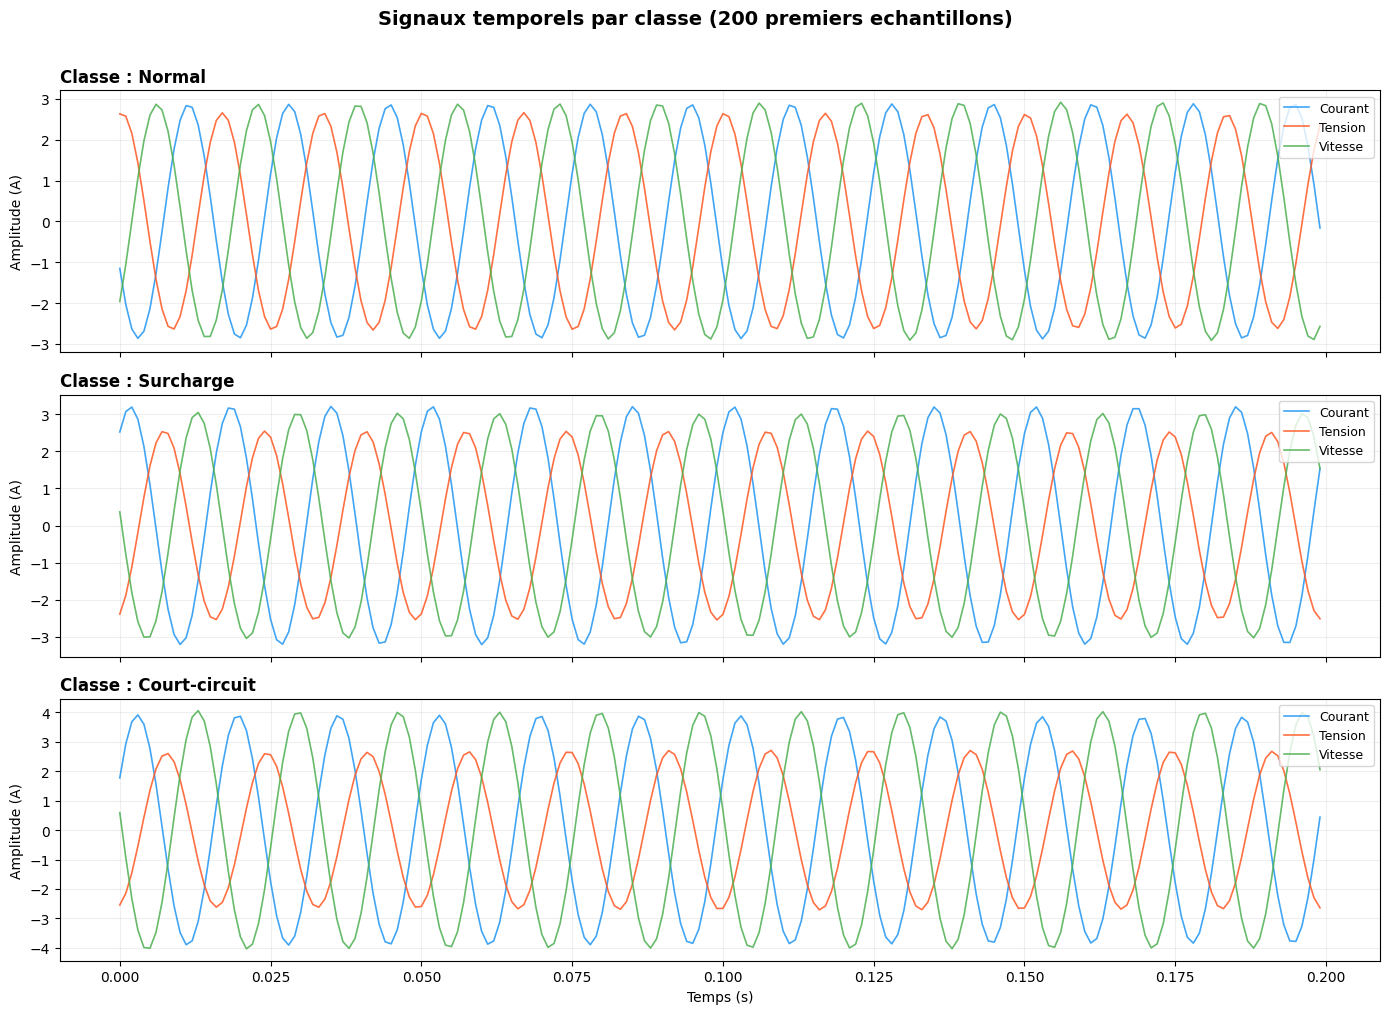

In [4]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
colors = ['#2196F3', '#FF5722', '#4CAF50']

for idx, label in enumerate(['Normal', 'Surcharge', 'Court-circuit']):
    ax = axes[idx]
    sample = [s for s in all_signals if s[1] == label][0][0]
    t = np.arange(200) / 1000  # Axe temporel en secondes
    for phase in range(3):
        ax.plot(t, sample[:200, phase], label=SENSOR_NAMES[phase],
                color=colors[phase], linewidth=1.2, alpha=0.85)
    ax.set_title(f'Classe : {label}', fontsize=12, fontweight='bold', loc='left')
    ax.set_ylabel('Amplitude (A)')
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(True, alpha=0.2)

axes[-1].set_xlabel('Temps (s)')
plt.suptitle('Signaux temporels par classe (200 premiers echantillons)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 4.2 Distribution statistique des amplitudes

La distribution des amplitudes permet de visualiser comment les défauts
modifient le comportement statistique des signaux.

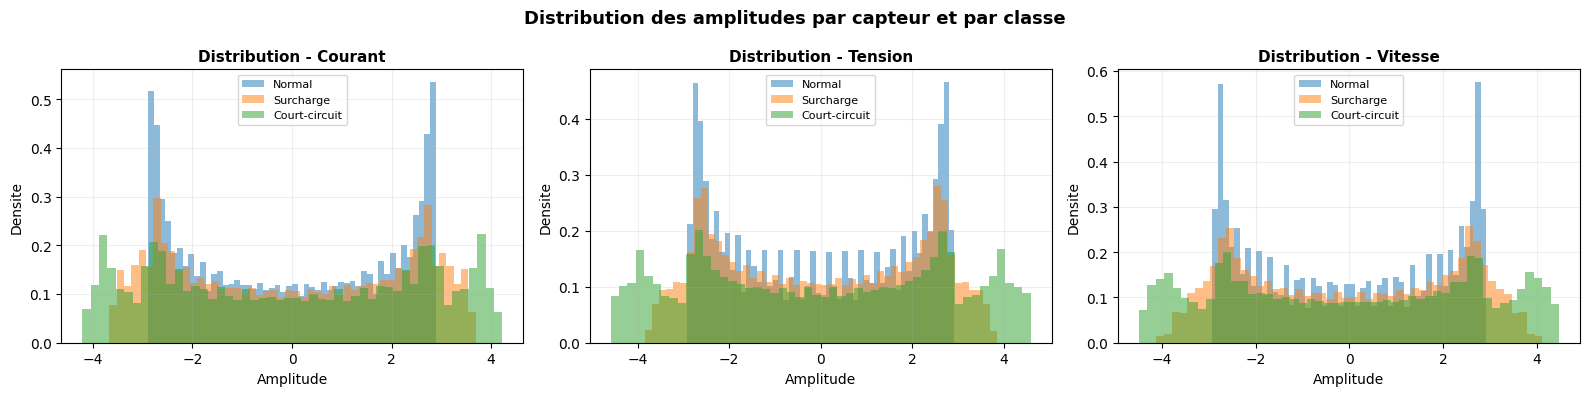

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for idx, sensor_idx in enumerate(range(3)):
    ax = axes[idx]
    for label in ['Normal', 'Surcharge', 'Court-circuit']:
        data = np.concatenate([s[0][:, sensor_idx] for s in all_signals if s[1] == label])
        ax.hist(data, bins=50, alpha=0.5, label=label, density=True)
    ax.set_title(f'Distribution - {SENSOR_NAMES[idx]}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Amplitude')
    ax.set_ylabel('Densite')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.2)

plt.suptitle('Distribution des amplitudes par capteur et par classe',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 5. Extraction des caractéristiques (Feature Engineering)

### 5.1 Stratégie d'extraction

Pour chaque signal de 1000 echantillons, on extrait un ensemble de
caractéristiques numériques qui résument le comportement du signal.
Ces caractéristiques sont calculables en temps réel sur ESP32.

On distingue deux familles de caractéristiques :

**Caractéristiques temporelles** (10 par capteur) :
- Moyenne, écart-type, valeur RMS
- Valeurs maximale et minimale, amplitude crête-à-crête
- Kurtosis (aplatissement), asymétrie (skewness)
- Variation absolue moyenne (MAD), intervalle interquartile (IQR)

**Caractéristiques fréquentielles** (5 par capteur) :
- Énergie spectrale totale
- Fréquence dominante
- Fréquence moyenne pondérée
- Dispersion spectrale (écart-type du spectre)
- Ratio du pic spectral

**Total : 15 caractéristiques x 3 capteurs = 45 caractéristiques par échantillon**

In [6]:
from scipy.stats import kurtosis, skew
from scipy.fft import fft

def extract_features(signal):
    """
    Extrait les caracteristiques d'un signal multi-capteur.
    
    Parametres
    ----------
    signal : ndarray de forme (n_samples, n_sensors)
        Signal temporel brut.
    
    Retour
    ------
    features : ndarray 1D
        Vecteur de caracteristiques extraites.
    """
    features = []
    n_samples = signal.shape[0]
    
    for sensor in range(signal.shape[1]):
        x = signal[:, sensor]
        
        # Caracteristiques temporelles
        mean_val = np.mean(x)
        std_val = np.std(x)
        rms_val = np.sqrt(np.mean(x ** 2))
        max_val = np.max(x)
        min_val = np.min(x)
        peak_to_peak = max_val - min_val
        kurt_val = kurtosis(x)
        skew_val = skew(x)
        mad_val = np.mean(np.abs(np.diff(x)))
        iqr_val = np.percentile(x, 75) - np.percentile(x, 25)
        
        # Caracteristiques frequentielles (FFT)
        spectrum = np.abs(fft(x))[:n_samples // 2]
        freqs = np.fft.fftfreq(n_samples, d=1.0 / 1000)[:n_samples // 2]
        
        spectral_energy = np.sum(spectrum ** 2)
        dominant_freq = freqs[np.argmax(spectrum)]
        mean_freq = np.sum(freqs * spectrum) / (np.sum(spectrum) + 1e-10)
        spectral_std = np.std(spectrum)
        spectral_peak_ratio = np.max(spectrum) / (np.sum(spectrum) + 1e-10)
        
        features.extend([
            mean_val, std_val, rms_val, max_val, min_val, peak_to_peak,
            kurt_val, skew_val, mad_val, iqr_val,
            spectral_energy, dominant_freq, mean_freq, spectral_std,
            spectral_peak_ratio
        ])
    
    return np.array(features)


# Construction des noms de caracteristiques
TEMPORAL_FEATURES = [
    'Mean', 'Std', 'RMS', 'Max', 'Min', 'PeakToPeak',
    'Kurtosis', 'Skewness', 'MAD', 'IQR'
]
SPECTRAL_FEATURES = [
    'SpectralEnergy', 'DominantFreq', 'MeanFreq',
    'SpectralStd', 'SpectralPeakRatio'
]
ALL_FEATURE_NAMES_PER_SENSOR = TEMPORAL_FEATURES + SPECTRAL_FEATURES

feature_names = []
for sensor in SENSOR_NAMES:
    for feat in ALL_FEATURE_NAMES_PER_SENSOR:
        feature_names.append(f'{sensor}_{feat}')

# Extraction sur l'ensemble du dataset
print("Extraction des caracteristiques en cours...")
X = np.array([extract_features(s[0]) for s in all_signals])
y = np.array([LABEL_TO_INT[s[1]] for s in all_signals])

print(f"Matrice de caracteristiques X : {X.shape}")
print(f"Vecteur de labels y           : {y.shape}")
print(f"Nombre de caracteristiques    : {len(feature_names)}")
print(f"  - Par capteur               : {len(ALL_FEATURE_NAMES_PER_SENSOR)}")
print(f"  - Temporelles               : {len(TEMPORAL_FEATURES)}")
print(f"  - Frequentielles            : {len(SPECTRAL_FEATURES)}")

Extraction des caracteristiques en cours...
Matrice de caracteristiques X : (65, 45)
Vecteur de labels y           : (65,)
Nombre de caracteristiques    : 45
  - Par capteur               : 15
  - Temporelles               : 10
  - Frequentielles            : 5


### 5.2 Aperçu de la matrice de caractéristiques

In [7]:
features_df = pd.DataFrame(X, columns=feature_names)
features_df['Classe'] = [list(LABEL_TO_INT.keys())[v] for v in y]
print("Statistiques descriptives des 10 premieres caracteristiques :\n")
print(features_df[feature_names[:10]].describe().round(4).to_string())

Statistiques descriptives des 10 premieres caracteristiques :

       Courant_Mean  Courant_Std  Courant_RMS  Courant_Max  Courant_Min  Courant_PeakToPeak  Courant_Kurtosis  Courant_Skewness  Courant_MAD  Courant_IQR
count       65.0000      65.0000      65.0000      65.0000      65.0000             65.0000           65.0000           65.0000      65.0000      65.0000
mean        -0.0000       2.3515       2.3515       3.3777      -3.3749              6.7526           -1.4980           -0.0000       0.7932       4.6828
std          0.0010       0.3462       0.3462       0.5117       0.5098              1.0214            0.0106            0.0005       0.1163       0.6786
min         -0.0048       1.8970       1.8970       2.7049      -4.2133              5.4096           -1.5003           -0.0015       0.6406       3.7690
25%         -0.0004       2.0088       2.0088       2.8800      -3.8806              5.7592           -1.4999           -0.0004       0.6777       4.0416
50%          

### 5.3 Matrice de corrélation

La matrice de corrélation permet d'identifier les caractéristiques
redondantes et celles qui sont les plus discriminantes.

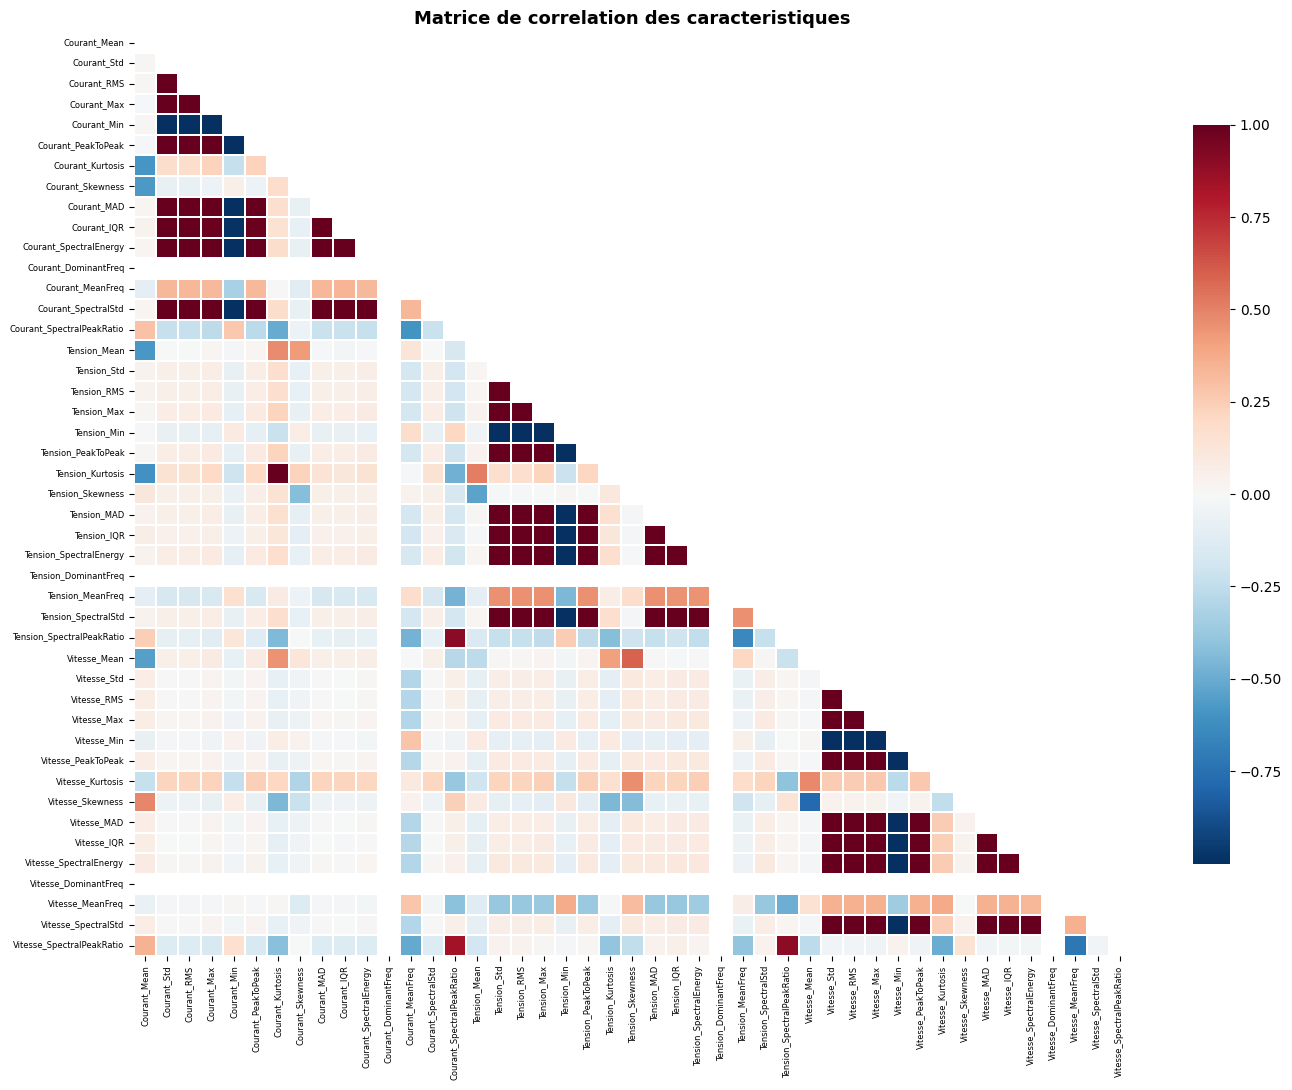

In [8]:
fig, ax = plt.subplots(figsize=(14, 11))
corr_matrix = features_df[feature_names].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, cmap='RdBu_r', center=0,
            ax=ax, linewidths=0.3, cbar_kws={'shrink': 0.8})
ax.set_title('Matrice de correlation des caracteristiques', fontsize=13, fontweight='bold')
plt.xticks(rotation=90, fontsize=6)
plt.yticks(fontsize=6)
plt.tight_layout()
plt.show()

---
## 6. Préparation des données pour l'entraînement

### 6.1 Partitionnement et normalisation

- **Partitionnement** : 80% entraînement / 20% test avec stratification
- **Normalisation** : StandardScaler (moyenne = 0, écart-type = 1)

La stratification garantit que la proportion de chaque classe est
conservée dans les ensembles d'entraînement et de test.

In [9]:
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Partitionnement des donnees :")
print(f"  Ensemble d'entrainement : {X_train_scaled.shape[0]} echantillons")
print(f"  Ensemble de test        : {X_test_scaled.shape[0]} echantillons")
print(f"\nDistribution par classe :")
class_labels = list(LABEL_TO_INT.keys())
for i, cls in enumerate(class_labels):
    n_train = np.sum(y_train == i)
    n_test = np.sum(y_test == i)
    print(f"  {cls:15s} : train={n_train:3d}, test={n_test:3d}")

Partitionnement des donnees :
  Ensemble d'entrainement : 52 echantillons
  Ensemble de test        : 13 echantillons

Distribution par classe :
  Normal          : train=  4, test=  1
  Surcharge       : train= 24, test=  6
  Court-circuit   : train= 24, test=  6


---
## 7. Entraînement et optimisation des classificateurs

### 7.1 Protocole expérimental

Chaque modèle est optimisé par **recherche exhaustive sur grille** (GridSearchCV)
avec **validation croisée stratifiée à 5 plis**. Les hyperparamètres optimaux
sont sélectionnés sur la base de l'accuracy moyenne de validation croisée.

### 7.2 Modèles évalués

| Modèle | Famille | Complexité ESP32 |
|--------|---------|------------------|
| Decision Tree | Arbre de décision | Faible |
| Random Forest | Ensemble (bagging) | Moyenne |
| KNN | Instance-based | Elevée (stockage données) |
| SVM linéaire | Marge maximale | Faible |
| Régression logistique | Modèle linéaire | Faible |
| Perceptron multicouche | Réseau de neurones | Moyenne |
| HistGradientBoosting | Ensemble (boosting) | Moyenne |
| XGBoost | Ensemble (boosting) | Moyenne |

In [10]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (RandomForestClassifier,
                               HistGradientBoostingClassifier)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix, f1_score)
import xgboost as xgb
import time

CLASS_NAMES = ['Normal', 'Surcharge', 'Court-circuit']

models_config = {
    'Decision Tree': {
        'estimator': DecisionTreeClassifier(random_state=42),
        'params': {
            'max_depth': [3, 5, 7, 10],
            'min_samples_split': [2, 5, 10],
            'min_samples_leaf': [1, 2, 4]
        },
        'compatible_esp32': True
    },
    'Random Forest': {
        'estimator': RandomForestClassifier(n_estimators=10, random_state=42),
        'params': {
            'max_depth': [5, 7, 10],
            'min_samples_split': [2, 5],
            'min_samples_leaf': [1, 2]
        },
        'compatible_esp32': True
    },
    'KNN': {
        'estimator': KNeighborsClassifier(),
        'params': {
            'n_neighbors': [3, 5, 7],
            'weights': ['uniform', 'distance'],
            'metric': ['euclidean', 'manhattan']
        },
        'compatible_esp32': False
    },
    'SVM Lineaire': {
        'estimator': LinearSVC(random_state=42, max_iter=5000, dual=False),
        'params': {
            'C': [0.01, 0.1, 1, 10]
        },
        'compatible_esp32': True
    },
    'Regression Logistique': {
        'estimator': LogisticRegression(random_state=42, max_iter=2000),
        'params': {
            'C': [0.01, 0.1, 1, 10]
        },
        'compatible_esp32': True
    },
    'Perceptron Multicouche': {
        'estimator': MLPClassifier(random_state=42, max_iter=1000,
                                    early_stopping=True),
        'params': {
            'hidden_layer_sizes': [(10,), (20,), (15, 10)],
            'activation': ['relu', 'tanh'],
            'alpha': [0.001, 0.01]
        },
        'compatible_esp32': True
    },
    'HistGradientBoosting': {
        'estimator': HistGradientBoostingClassifier(random_state=42,
                                                     max_iter=100),
        'params': {
            'max_depth': [3, 5, 7],
            'learning_rate': [0.05, 0.1, 0.2],
            'min_samples_leaf': [5, 10, 20]
        },
        'compatible_esp32': True
    },
    'XGBoost': {
        'estimator': xgb.XGBClassifier(random_state=42, n_estimators=50,
                                        use_label_encoder=False,
                                        eval_metric='mlogloss',
                                        verbosity=0),
        'params': {
            'max_depth': [3, 5, 7],
            'learning_rate': [0.05, 0.1, 0.2],
            'subsample': [0.8, 1.0]
        },
        'compatible_esp32': True
    },
}

In [11]:
# Entrainement avec GridSearchCV
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = {}

for name, config in models_config.items():
    print(f"\n{'=' * 65}")
    print(f" {name}")
    print(f"{'=' * 65}")
    
    t_start = time.time()
    
    grid_search = GridSearchCV(
        estimator=config['estimator'],
        param_grid=config['params'],
        cv=cv_strategy,
        scoring='accuracy',
        n_jobs=-1,
        refit=True
    )
    grid_search.fit(X_train_scaled, y_train)
    
    y_pred = grid_search.predict(X_test_scaled)
    test_acc = accuracy_score(y_test, y_pred)
    cv_acc = grid_search.best_score_
    f1 = f1_score(y_test, y_pred, average='weighted')
    elapsed = time.time() - t_start
    
    results[name] = {
        'model': grid_search.best_estimator_,
        'test_accuracy': test_acc,
        'cv_accuracy': cv_acc,
        'f1_score': f1,
        'best_params': grid_search.best_params_,
        'y_pred': y_pred,
        'time': elapsed,
        'compatible_esp32': config['compatible_esp32']
    }
    
    print(f"  Accuracy (validation croisee) : {cv_acc:.4f}")
    print(f"  Accuracy (test)               : {test_acc:.4f}")
    print(f"  F1-score (pondere)            : {f1:.4f}")
    print(f"  Temps d'entrainement          : {elapsed:.2f} s")
    print(f"  Hyperparametres optimaux      : {grid_search.best_params_}")
    print(f"\n{classification_report(y_test, y_pred, target_names=CLASS_NAMES)}")


 Decision Tree
  Accuracy (validation croisee) : 0.9255
  Accuracy (test)               : 0.8462
  F1-score (pondere)            : 0.8462
  Temps d'entrainement          : 5.10 s
  Hyperparametres optimaux      : {'max_depth': 3, 'min_samples_leaf': 2, 'min_samples_split': 2}

               precision    recall  f1-score   support

       Normal       0.00      0.00      0.00         1
    Surcharge       0.83      0.83      0.83         6
Court-circuit       1.00      1.00      1.00         6

     accuracy                           0.85        13
    macro avg       0.61      0.61      0.61        13
 weighted avg       0.85      0.85      0.85        13


 Random Forest
  Accuracy (validation croisee) : 0.9055
  Accuracy (test)               : 0.9231
  F1-score (pondere)            : 0.8876
  Temps d'entrainement          : 0.32 s
  Hyperparametres optimaux      : {'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2}

               precision    recall  f1-score   support

---
## 8. Évaluation comparative des modèles

### 8.1 Tableau récapitulatif

In [12]:
comparison = pd.DataFrame({
    'Modele': list(results.keys()),
    'CV Accuracy': [r['cv_accuracy'] for r in results.values()],
    'Test Accuracy': [r['test_accuracy'] for r in results.values()],
    'F1-Score': [r['f1_score'] for r in results.values()],
    'Temps (s)': [r['time'] for r in results.values()],
    'ESP32': ['Oui' if r['compatible_esp32'] else 'Non' for r in results.values()],
})
comparison = comparison.sort_values('Test Accuracy', ascending=False).reset_index(drop=True)

print("=" * 80)
print(" CLASSEMENT DES MODELES")
print("=" * 80)
print(comparison.to_string(index=False))

 CLASSEMENT DES MODELES
                Modele  CV Accuracy  Test Accuracy  F1-Score  Temps (s) ESP32
         Random Forest     0.905455       0.923077  0.887574   0.317065   Oui
          SVM Lineaire     0.863636       0.923077  0.887574   0.047013   Oui
  HistGradientBoosting     0.923636       0.923077  0.887574   4.556380   Oui
 Regression Logistique     0.881818       0.923077  0.922539   0.065012   Oui
               XGBoost     0.905455       0.923077  0.887574   1.463787   Oui
         Decision Tree     0.925455       0.846154  0.846154   5.103002   Oui
                   KNN     0.863636       0.769231  0.753846   2.849679   Non
Perceptron Multicouche     0.634545       0.384615  0.398601   0.239532   Oui


### 8.2 Matrices de confusion

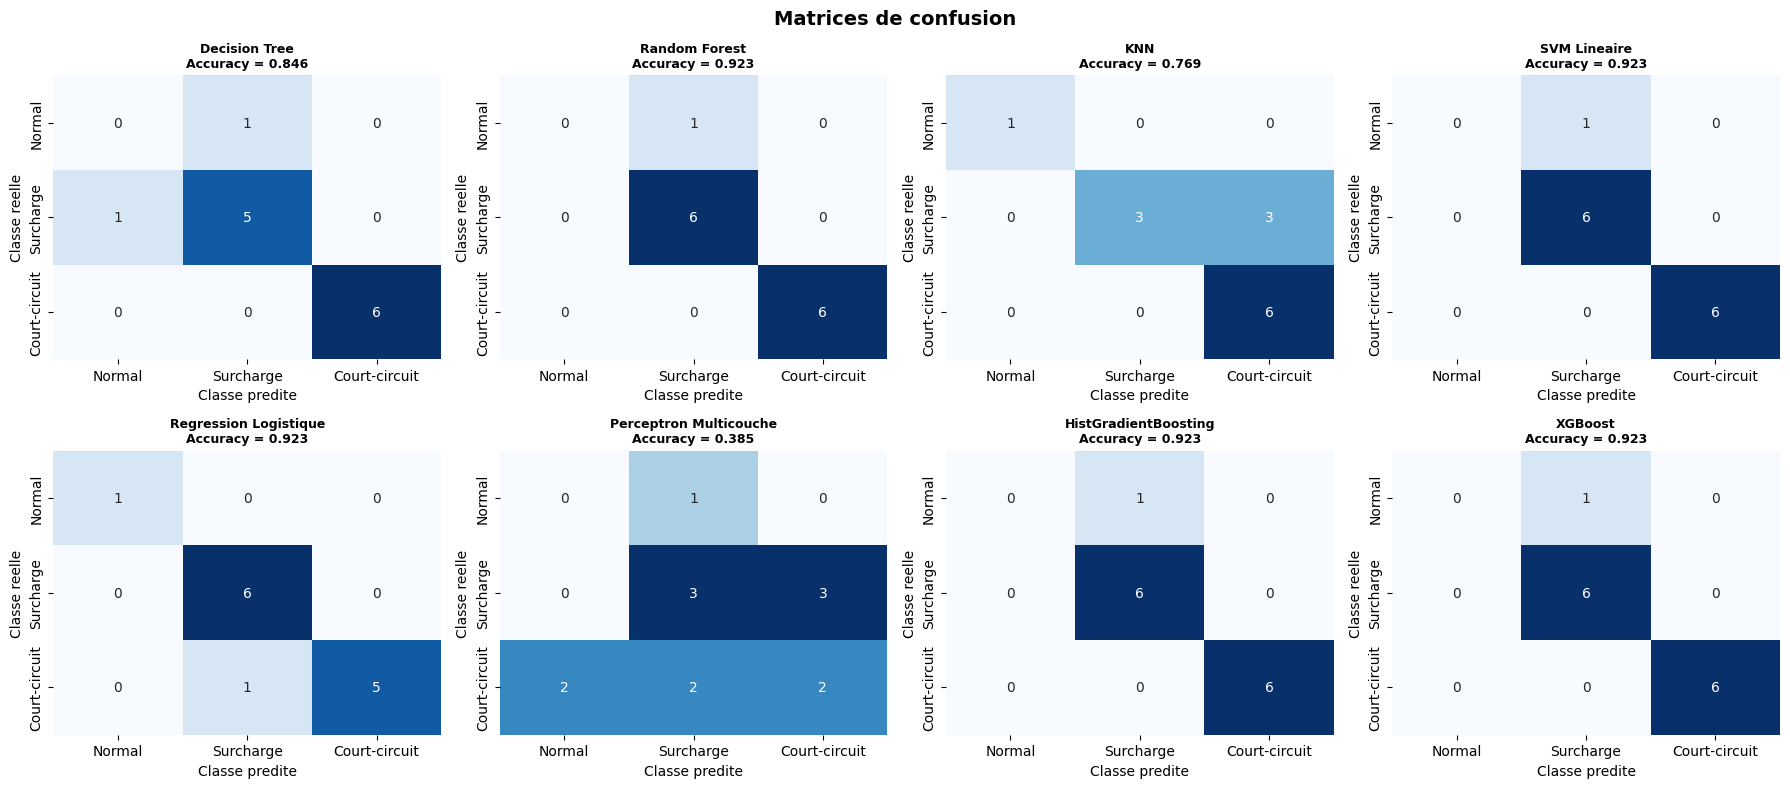

In [13]:
n_models = len(results)
ncols = 4
nrows = (n_models + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 4.5, nrows * 4))
axes_flat = axes.flatten()

for idx, (name, res) in enumerate(results.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes_flat[idx],
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, cbar=False)
    axes_flat[idx].set_title(f'{name}\nAccuracy = {res["test_accuracy"]:.3f}',
                             fontsize=9, fontweight='bold')
    axes_flat[idx].set_ylabel('Classe reelle')
    axes_flat[idx].set_xlabel('Classe predite')

for idx in range(len(results), len(axes_flat)):
    axes_flat[idx].set_visible(False)

plt.suptitle('Matrices de confusion', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 8.3 Comparaison graphique des performances

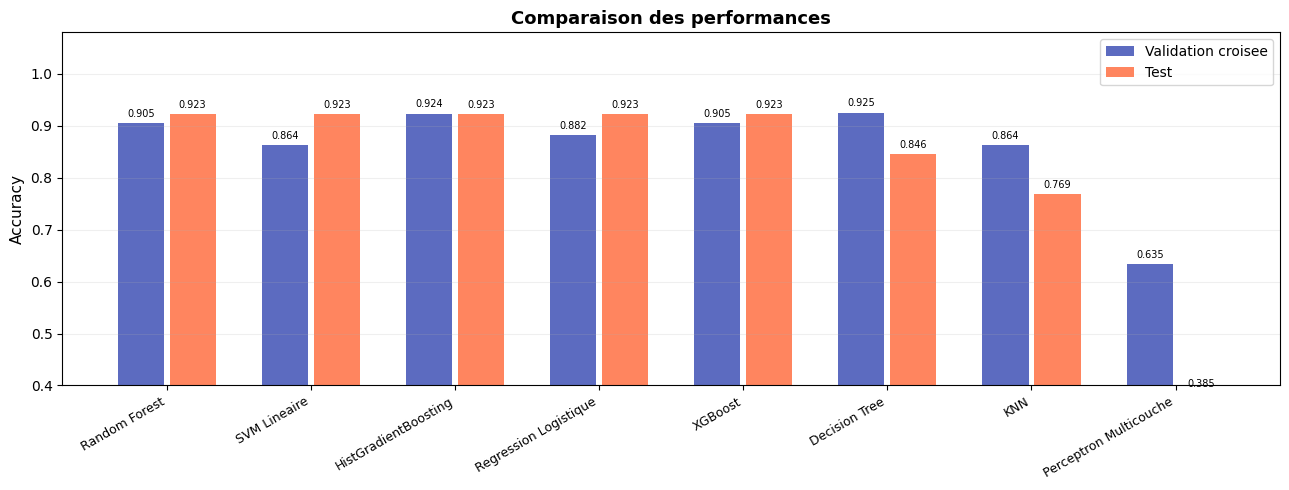

In [14]:
fig, ax = plt.subplots(figsize=(13, 5))
model_names = comparison['Modele'].tolist()
cv_acc_vals = comparison['CV Accuracy'].tolist()
test_acc_vals = comparison['Test Accuracy'].tolist()
x = np.arange(len(model_names))

b1 = ax.bar(x - 0.18, cv_acc_vals, 0.32, label='Validation croisee',
            color='#3F51B5', alpha=0.85)
b2 = ax.bar(x + 0.18, test_acc_vals, 0.32, label='Test',
            color='#FF7043', alpha=0.85)

ax.set_ylabel('Accuracy', fontsize=11)
ax.set_title('Comparaison des performances', fontweight='bold', fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=30, ha='right', fontsize=9)
ax.legend(fontsize=10)
ax.set_ylim(0.4, 1.08)
ax.grid(axis='y', alpha=0.2)

for bars in [b1, b2]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2., h + 0.008,
                f'{h:.3f}', ha='center', va='bottom', fontsize=7)

plt.tight_layout()
plt.show()

---
## 9. Analyse de l'importance des caractéristiques

L'importance des caractéristiques permet d'identifier quels signaux
et quelles propriétés statistiques sont les plus discriminantes
pour la classification des défauts.

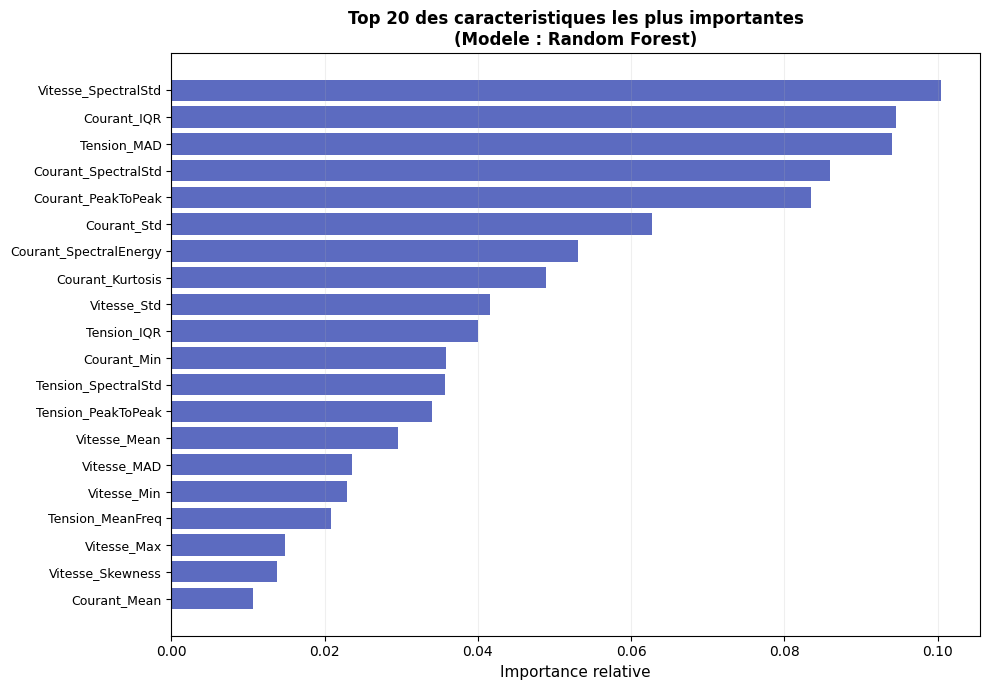


Repartition de l'importance par capteur :
  Courant    : 0.4850 (48.5%)
  Tension    : 0.2580 (25.8%)
  Vitesse    : 0.2570 (25.7%)


In [15]:
tree_based = {k: v for k, v in results.items()
              if hasattr(v['model'], 'feature_importances_')}

if tree_based:
    best_tree_name = max(tree_based, key=lambda k: tree_based[k]['test_accuracy'])
    importances = tree_based[best_tree_name]['model'].feature_importances_
    sorted_idx = np.argsort(importances)[-20:]

    fig, ax = plt.subplots(figsize=(10, 7))
    bars = ax.barh(range(len(sorted_idx)), importances[sorted_idx],
                   color='#3F51B5', alpha=0.85)
    ax.set_yticks(range(len(sorted_idx)))
    ax.set_yticklabels([feature_names[i] for i in sorted_idx], fontsize=9)
    ax.set_xlabel('Importance relative', fontsize=11)
    ax.set_title(f'Top 20 des caracteristiques les plus importantes\n'
                 f'(Modele : {best_tree_name})',
                 fontweight='bold', fontsize=12)
    ax.grid(axis='x', alpha=0.2)
    plt.tight_layout()
    plt.show()
    
    print("\nRepartition de l'importance par capteur :")
    for sensor in SENSOR_NAMES:
        mask = [i for i, name in enumerate(feature_names) if name.startswith(sensor)]
        total_imp = np.sum(importances[mask])
        print(f"  {sensor:10s} : {total_imp:.4f} ({total_imp*100:.1f}%)")

---
## 10. Exportation du modèle pour ESP32

### 10.1 Sélection du modèle optimal

On sélectionne le meilleur modèle parmi ceux compatibles avec l'ESP32
(exclusion du KNN qui nécessite le stockage de toutes les données d'entraînement).

### 10.2 Conversion en code C

La bibliothèque `m2cgen` (Model to Code Generator) convertit les modèles
scikit-learn en code C natif, directement compilable sur ESP32.

In [16]:
import m2cgen as m2c

# Selection du meilleur modele compatible ESP32
esp32_models = {k: v for k, v in results.items() if v['compatible_esp32']}
best_name = max(esp32_models, key=lambda k: esp32_models[k]['test_accuracy'])
best_model = esp32_models[best_name]['model']

print("=" * 65)
print(" MODELE SELECTIONNE POUR ESP32")
print("=" * 65)
print(f"  Nom                : {best_name}")
print(f"  Accuracy (test)    : {esp32_models[best_name]['test_accuracy']:.4f}")
print(f"  F1-Score           : {esp32_models[best_name]['f1_score']:.4f}")
print(f"  Hyperparametres    : {esp32_models[best_name]['best_params']}")

 MODELE SELECTIONNE POUR ESP32
  Nom                : Random Forest
  Accuracy (test)    : 0.9231
  F1-Score           : 0.8876
  Hyperparametres    : {'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2}


In [17]:
# Generation du code C
c_code = m2c.export_to_c(best_model)

model_file = 'model_esp32.c'
with open(model_file, 'w') as f:
    f.write('/*\n')
    f.write(f' * Modele de classification : {best_name}\n')
    f.write(f' * Accuracy sur le jeu de test : {esp32_models[best_name]["test_accuracy"]:.4f}\n')
    f.write(f' * Nombre de caracteristiques en entree : {len(feature_names)}\n')
    f.write(f' * Classes de sortie : 0=Normal, 1=Surcharge, 2=Court-circuit\n')
    f.write(' */\n\n')
    f.write(c_code)

print(f"\nFichier genere : {model_file}")
print(f"Taille         : {os.path.getsize(model_file) / 1024:.1f} Ko")
print(f"\nExtrait du code genere :")
lines = c_code.split('\n')
for line in lines[:15]:
    print(f"  {line}")


Fichier genere : model_esp32.c
Taille         : 10.1 Ko

Extrait du code genere :
  #include <string.h>
  void add_vectors(double *v1, double *v2, int size, double *result) {
      for(int i = 0; i < size; ++i)
          result[i] = v1[i] + v2[i];
  }
  void mul_vector_number(double *v1, double num, int size, double *result) {
      for(int i = 0; i < size; ++i)
          result[i] = v1[i] * num;
  }
  void score(double * input, double * output) {
      double var0[3];
      double var1[3];
      double var2[3];
      double var3[3];
      double var4[3];


In [18]:
# Export des parametres du scaler
scaler_file = 'scaler_params.h'
with open(scaler_file, 'w') as f:
    f.write('/*\n')
    f.write(' * Parametres de normalisation StandardScaler\n')
    f.write(f' * Nombre de caracteristiques : {len(feature_names)}\n')
    f.write(' * Formule : x_norm = (x - mean) / scale\n')
    f.write(' */\n\n')
    f.write('#ifndef SCALER_PARAMS_H\n')
    f.write('#define SCALER_PARAMS_H\n\n')
    f.write(f'#define N_FEATURES {len(feature_names)}\n')
    f.write(f'#define N_CLASSES 3\n\n')
    f.write('const float scaler_mean[N_FEATURES] = {\n    ')
    f.write(',\n    '.join(f'{v:.8f}f' for v in scaler.mean_))
    f.write('\n};\n\n')
    f.write('const float scaler_scale[N_FEATURES] = {\n    ')
    f.write(',\n    '.join(f'{v:.8f}f' for v in scaler.scale_))
    f.write('\n};\n\n')
    f.write('#endif\n')

print(f"Fichier genere : {scaler_file}")

Fichier genere : scaler_params.h


---
## 11. Guide d'intégration sur ESP32

### 11.1 Architecture du système embarqué

```
[Capteur Courant] ---> [ADC ESP32] ---+
[Capteur Tension] ---> [ADC ESP32] ---+--> [Extraction features] --> [Modele ML] --> [Decision]
[Capteur Vitesse] ---> [ADC ESP32] ---+
```

### 11.2 Étapes d'intégration

1. Connecter les capteurs aux broches ADC de l'ESP32
2. Echantillonner les 3 signaux a 1 kHz pendant 1 seconde
3. Calculer les 45 caracteristiques (voir section 5)
4. Normaliser avec les parametres de `scaler_params.h`
5. Appeler la fonction `score()` generee dans `model_esp32.c`
6. Interpreter le resultat (index du maximum = classe predite)

### 11.3 Exemple de code Arduino/ESP32

```c
#include "model_esp32.c"
#include "scaler_params.h"

// Fonction de prediction
int predict_motor_state(float features[N_FEATURES]) {
    float scaled[N_FEATURES];
    
    // Etape 1 : Normalisation
    for (int i = 0; i < N_FEATURES; i++) {
        scaled[i] = (features[i] - scaler_mean[i]) / scaler_scale[i];
    }
    
    // Etape 2 : Inference
    double output[N_CLASSES];
    score(scaled, output);
    
    // Etape 3 : Selection de la classe
    int predicted_class = 0;
    for (int i = 1; i < N_CLASSES; i++) {
        if (output[i] > output[predicted_class]) {
            predicted_class = i;
        }
    }
    
    return predicted_class;
    // 0 = Normal, 1 = Surcharge, 2 = Court-circuit
}
```

In [19]:
# Resume final
print("\n" + "=" * 65)
print(" RESUME FINAL")
print("=" * 65)
print(f"\n  Modele selectionne    : {best_name}")
print(f"  Accuracy (test)       : {esp32_models[best_name]['test_accuracy']:.4f}")
print(f"  F1-Score (pondere)    : {esp32_models[best_name]['f1_score']:.4f}")
print(f"\n  Fichiers generes :")
print(f"    - {model_file:25s} (code C du modele)")
print(f"    - {scaler_file:25s} (parametres de normalisation)")
print(f"\n  Classement complet :")
print(comparison.to_string(index=False))


 RESUME FINAL

  Modele selectionne    : Random Forest
  Accuracy (test)       : 0.9231
  F1-Score (pondere)    : 0.8876

  Fichiers generes :
    - model_esp32.c             (code C du modele)
    - scaler_params.h           (parametres de normalisation)

  Classement complet :
                Modele  CV Accuracy  Test Accuracy  F1-Score  Temps (s) ESP32
         Random Forest     0.905455       0.923077  0.887574   0.317065   Oui
          SVM Lineaire     0.863636       0.923077  0.887574   0.047013   Oui
  HistGradientBoosting     0.923636       0.923077  0.887574   4.556380   Oui
 Regression Logistique     0.881818       0.923077  0.922539   0.065012   Oui
               XGBoost     0.905455       0.923077  0.887574   1.463787   Oui
         Decision Tree     0.925455       0.846154  0.846154   5.103002   Oui
                   KNN     0.863636       0.769231  0.753846   2.849679   Non
Perceptron Multicouche     0.634545       0.384615  0.398601   0.239532   Oui
